# Efeito de lemmatização e remoção de stopwords. 
- A remoção de stopwords geralmente é benéfica aos estudos do estilo "bag of words" ou TFIDF, uma vez que os termos ditos "stopwords" geralmente são palvras que nao acrescentam muito ao contexto dos textos. 
- A lemmatização e stem são técnicas que também reduzem o vocabulário do problema, ao "aglutinar" termos, flexões verbais, plurais, etc em um termo que passa o significado geral (ex lemma: caiu, cai -> cair; amigos -> amigo).

- É importante dizer que nem sempre melhora é verificada, como será mostrado aqui. No caso do TFIDF, existe uma tendencia natural de reduzir (e não eliminá-la) a influência de stopwords pela pela divisão pela frequência do termo. A lemmatização, por sua vez, é uma transformação textual, e pode retirar propriedades importantes do texto, como o tempo verbal característico, que poderia ser importante para a identificação do um estilo ou época.

- A seguir, será feito um estudo da influência da remoção de stopwords e da lemmatização, sendo feitos em separado e em conjunto. Ao final, será comparado os resultados com o tido como "baseline", e não utilizou essas técnicas.

# Imports e configs

In [1]:
import pandas as pd
import spacy
from tqdm.auto import tqdm
from unidecode import unidecode
import re
import os
import numpy as np
tqdm.pandas()

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import lightgbm as lgb
from sklearn.pipeline import make_pipeline
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, average_precision_score,
                             balanced_accuracy_score, roc_auc_score, confusion_matrix)
from sklearn.utils.class_weight import compute_sample_weight
from imblearn.metrics import geometric_mean_score

# Configs
split_path = '../data/split'
seed = 2025

import warnings, time
warnings.filterwarnings("ignore", message=".*does not have valid feature names.*", category=UserWarning)


# Paths
path_data = '../data'
path_data_split = f'{path_data}/split'
path_data_raw = f'{path_data}/raw/booksummaries.txt'
path_data_split_train = f'{path_data_split}/train_val_set.csv'
path_data_split_test = f'{path_data_split}/test_set.csv'

# Recuperação dos dados crus

In [2]:
# ler como TSV (tab-separated)
df_raw = pd.read_table(path_data_raw, header=None)
df_raw.columns = [
    "id", 
    "freebase_id", 
    "title", 
    "author", 
    "publication_date", 
    "genres", 
    "summary"
]

df_raw['text_raw'] = df_raw['title'] + '. \n ' + df_raw['summary']
df_raw = df_raw[['id', 'text_raw']].set_index('id')
df_raw.head(2)

,text_raw
id,
620,"Animal Farm. \n Old Major, the old boar on th..."
843,"A Clockwork Orange. \n Alex, a teenager livin..."


# Recuperação dos datasets
    - pelos ids poderemos associá-los

In [3]:
df_train = pd.read_csv(path_data_split_train)[['id', 'fold', 'label']]
df_test = pd.read_csv(path_data_split_test)[['id', 'fold','label']]

df = pd.concat([df_train, df_test], ignore_index=True).set_index('id')
df = pd.concat([df, df_raw], axis=1).dropna()
df

,fold,label,text_raw
id,,,
620,fold_3,0.0,"Animal Farm. \n Old Major, the old boar on th..."
843,fold_2,0.0,"A Clockwork Orange. \n Alex, a teenager livin..."
986,fold_1,0.0,The Plague. \n The text of The Plague is divi...
2080,fold_4,0.0,A Fire Upon the Deep. \n The novel posits tha...
4082,fold_5,0.0,Blade Runner 2: The Edge of Human. \n Beginni...
...,...,...,...
33904029,test,0.0,Wild About Harry. \n In Paraguay an English M...
34356369,test,0.0,Of Wee Sweetie Mice and Men. \n Protagonist D...
34397231,test,0.0,The Horse With My Name. \n This novel follows...


# Rotinas de tratamento e avaliação

In [4]:
nlp = spacy.load("en_core_web_sm", disable=["ner", "parser"])

############################################################
# Rotina de tratamento generalizada
############################################################

def preprocess_text(
    text,
    lemmatize: bool = True,
    remove_stopwords: bool = True,
    min_len: int = 3,
    only_alpha: bool = True
):
    """
    Preprocessa texto em inglês com opções configuráveis.
    
    Args:
        text (str): Texto bruto.
        lemmatize (bool): Se True, usa lemma. Se False, usa token normal.
        remove_stopwords (bool): Se True, remove stopwords padrão do spaCy.
        min_len (int): Remove tokens com menos de N caracteres.
        only_alpha (bool): Se True, mantém apenas tokens alfabéticos.
    """
    doc = nlp(text)
    tokens = []
    for token in doc:
        # stopwords
        if remove_stopwords and token.is_stop:
            continue
        # pontuação
        if token.is_punct:
            continue
        # escolher lemma ou forma original
        tok = token.lemma_ if lemmatize else token.text
        if tok != "":
            tokens.append(tok.lower())

    clean_text = " ".join(tokens)

    # remover acentos
    clean_text = unidecode(clean_text)

    # remover caracteres especiais
    clean_text = re.sub(r"[^\w\s]", "", clean_text)

    # split para aplicar filtros finais
    words = clean_text.split()

    # filtros finais
    if only_alpha:
        words = [w for w in words if w.isalpha()]
    if min_len > 0:
        words = [w for w in words if len(w) >= min_len]

    # normalizar espaços
    clean_text = " ".join(words)
    return clean_text

############################################################
# Rotinas de validação cruzada
############################################################

def plot_confusion_matrix(cm, labels, model_name, normalized=False):
    """Plota matriz de confusão média."""
    plt.figure(figsize=(6, 5))
    fmt = ".2f" if normalized else "d"
    sns.heatmap(cm, annot=True, fmt=fmt, cmap="Blues",
                xticklabels=labels, yticklabels=labels)
    plt.xlabel("Predito"); plt.ylabel("Real")
    norm_txt = " (Normalizada)" if normalized else ""
    plt.title(f"Matriz de Confusão MÉDIA{norm_txt} - {model_name}")
    plt.tight_layout(); plt.show()


def roc_auc_safe(y_true, proba, classes_sorted):
    if len(classes_sorted) == 2:
        pos_idx = list(classes_sorted).index(classes_sorted[-1])
        return roc_auc_score(y_true, proba[:, pos_idx])
    return roc_auc_score(y_true, proba, multi_class="ovr", average="weighted")


def format_summary(results_detailed):
    """Formata em media (min-max) ± std com 2 casas."""
    rows = []
    for entry in results_detailed:
        row = {"Modelo": entry["Modelo"]}
        for metric, values in entry.items():
            if metric == "Modelo": 
                continue
            arr = np.array(values)
            row[metric] = f"{np.mean(arr):.2f} ({np.min(arr):.2f}-{np.max(arr):.2f}) ± {np.std(arr, ddof=1):.2f}"
        rows.append(row)
    return pd.DataFrame(rows)


def run_folds(model, model_name, df, labels_sorted, use_class_weight, log_each_fold):
    """Executa K folds para um modelo e retorna métricas fold a fold + matrizes médias."""
    fold_metrics, cms, cms_norm = [], [], []

    for fold in tqdm(sorted(df['fold'].unique()), desc=f"Folds {model_name}", leave=True):
        # split
        train_mask = df['fold'] != fold
        val_mask   = ~train_mask
        X_train_text = df.loc[train_mask, 'text'].astype(str).values
        X_val_text   = df.loc[val_mask, 'text'].astype(str).values
        y_train = df.loc[train_mask, 'label'].values
        y_val   = df.loc[val_mask, 'label'].values

        # TF-IDF sem vazamento
        vect = TfidfVectorizer()
        X_train = vect.fit_transform(X_train_text)
        X_val   = vect.transform(X_val_text)

        # treino com pesos se necessário
        if use_class_weight and model_name == "NaiveBayes":
            sw = compute_sample_weight(class_weight='balanced', y=y_train)
            model.fit(X_train, y_train, sample_weight=sw)
        else:
            model.fit(X_train, y_train)

        preds = model.predict(X_val)
        proba = model.predict_proba(X_val)

        metrics = {
            "Accuracy": accuracy_score(y_val, preds),
            "Precision": precision_score(y_val, preds, average="macro", zero_division=0),
            "Recall": recall_score(y_val, preds, average="macro", zero_division=0),
            "F1": f1_score(y_val, preds, average="macro", zero_division=0),
            "BalancedAccuracy": balanced_accuracy_score(y_val, preds),
            "GMean": geometric_mean_score(y_val, preds, average="binary"),
            "GMeanMicro": geometric_mean_score(y_val, preds, average="micro"),
            "AUPRC": average_precision_score(y_val, proba[:, 1])
        }
        fold_metrics.append(metrics)

        cm  = confusion_matrix(y_val, preds, labels=labels_sorted)
        cmn = confusion_matrix(y_val, preds, labels=labels_sorted, normalize="true")
        cms.append(cm); cms_norm.append(cmn)

        if log_each_fold:
            print(f"{model_name} | fold={fold} | " + " | ".join([f"{k}={v:.3f}" for k,v in metrics.items()]))

    # matrizes médias
    mean_cm = np.rint(np.mean(cms, axis=0)).astype(int)
    mean_cm_norm = np.mean(cms_norm, axis=0)
    return fold_metrics, mean_cm, mean_cm_norm


def evaluate_models(df, seed, use_class_weight=False, log_each_fold=False):
    labels_sorted = np.array(sorted(df['label'].unique()))

    models = {
        "NaiveBayes": MultinomialNB(),
        "LogisticRegression": LogisticRegression(random_state=seed, **({"class_weight":"balanced"} if use_class_weight else {})),
        "LightGBM": lgb.LGBMClassifier(random_state=seed, verbosity=-1, **({"class_weight":"balanced"} if use_class_weight else {})),
    }

    results, results_detailed = [], []

    for model_name, model in models.items():
        start = time.perf_counter()
        fold_metrics, mean_cm, mean_cm_norm = run_folds(model, model_name, df, labels_sorted, use_class_weight, log_each_fold)
        elapsed = time.perf_counter() - start

        # médias
        mean_vals = {k: np.mean([m[k] for m in fold_metrics]) for k in fold_metrics[0]}
        mean_vals.update({"Modelo": model_name, "Tempo_s": round(elapsed, 2)})
        results.append(mean_vals)

        # detalhado
        detailed_vals = {"Modelo": model_name}
        for k in fold_metrics[0]:
            detailed_vals[k] = [m[k] for m in fold_metrics]
        results_detailed.append(detailed_vals)

        # plot lado a lado
        fig, axes = plt.subplots(1, 2, figsize=(12, 5))

        sns.heatmap(mean_cm, annot=True, fmt="d", cmap="Blues",
                    xticklabels=labels_sorted, yticklabels=labels_sorted, ax=axes[0])
        axes[0].set_xlabel("Predito"); axes[0].set_ylabel("Real")
        axes[0].set_title(f"Matriz de Confusão MÉDIA - {model_name}")

        sns.heatmap(mean_cm_norm, annot=True, fmt=".2f", cmap="Blues",
                    xticklabels=labels_sorted, yticklabels=labels_sorted, ax=axes[1])
        axes[1].set_xlabel("Predito"); axes[1].set_ylabel("Real")
        axes[1].set_title(f"Matriz de Confusão MÉDIA (Normalizada) - {model_name}")

        plt.tight_layout()
        plt.show()

    metrics_df = pd.DataFrame(results).round(2)
    metrics_summary = format_summary(results_detailed)
    return metrics_df, metrics_summary


############################################################
# Rotinas de avaliação no conjunto de test
############################################################

def evaluate_on_test(train_df, test_df, seed, use_class_weight=False):
    labels_sorted = np.array(sorted(train_df['label'].unique()))

    models = {
        "NaiveBayes": MultinomialNB(),
        "LogisticRegression": LogisticRegression(
            random_state=seed, **({"class_weight": "balanced"} if use_class_weight else {})
        ),
        "LightGBM": lgb.LGBMClassifier(
            random_state=seed, verbosity=-1, **({"class_weight": "balanced"} if use_class_weight else {})
        ),
    }

    results = []

    X_train_text = train_df['text'].astype(str).values
    y_train = train_df['label'].values
    X_test_text = test_df['text'].astype(str).values
    y_test = test_df['label'].values

    for model_name, model in models.items():
        # TF-IDF no treino inteiro
        vect = TfidfVectorizer()
        X_train = vect.fit_transform(X_train_text)
        X_test = vect.transform(X_test_text)

        # pesos só no NaiveBayes se solicitado
        if use_class_weight and model_name == "NaiveBayes":
            sw = compute_sample_weight(class_weight="balanced", y=y_train)
            model.fit(X_train, y_train, sample_weight=sw)
        else:
            model.fit(X_train, y_train)

        preds = model.predict(X_test)
        proba = model.predict_proba(X_test)

        metrics = {
            "Modelo": model_name,
            "Accuracy": accuracy_score(y_test, preds),
            "Precision": precision_score(y_test, preds, average="macro", zero_division=0),
            "Recall": recall_score(y_test, preds, average="macro", zero_division=0),
            "F1": f1_score(y_test, preds, average="macro", zero_division=0),
            "BalancedAccuracy": balanced_accuracy_score(y_test, preds),
            "GMean": geometric_mean_score(y_test, preds, average="binary"),
            "GMeanMicro": geometric_mean_score(y_test, preds, average="micro"),
            "AUPRC": average_precision_score(y_test, proba[:, 1]),
        }
        results.append(metrics)

        # matrizes de confusão lado a lado
        cm = confusion_matrix(y_test, preds, labels=labels_sorted)
        cmn = confusion_matrix(y_test, preds, labels=labels_sorted, normalize="true")

        fig, axes = plt.subplots(1, 2, figsize=(12, 5))

        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                    xticklabels=labels_sorted, yticklabels=labels_sorted, ax=axes[0])
        axes[0].set_xlabel("Predito"); axes[0].set_ylabel("Real")
        axes[0].set_title(f"Matriz de Confusão - {model_name}")

        sns.heatmap(cmn, annot=True, fmt=".2f", cmap="Blues",
                    xticklabels=labels_sorted, yticklabels=labels_sorted, ax=axes[1])
        axes[1].set_xlabel("Predito"); axes[1].set_ylabel("Real")
        axes[1].set_title(f"Matriz de Confusão (Normalizada) - {model_name}")

        plt.tight_layout()
        plt.show()

    return pd.DataFrame(results).round(2)

############################################################
# Rotinas auxiliares
############################################################

# Split train test
def get_train_test_by_total_with_folds(df_total):
    df = df_total.copy()
    df_test = df[df['fold'] == 'test'].copy().reset_index(drop=True)
    df_train_val = df[df['fold'] != 'test'].copy().reset_index(drop=True)
    return df_test, df_train_val

# Calcular novo número de features
def show_number_of_features(df, column='text', return_vocab=False):
    vectorizer = CountVectorizer()
    X = vectorizer.fit_transform(df['text'])
    vocab = vectorizer.get_feature_names_out()
    vocab_size = len(vocab)
    print(f'Tamanho do novo vocabulário: {vocab_size}')
    if return_vocab:
        return vocab
    
# Apresentação de resultados por modelo
def show_results_by_model(results_dict, title="Resultados", display_df=True, return_dfs=False):
    # pegar todos os modelos que existem em pelo menos um DF
    modelos = set()
    for df in results_dict.values():
        modelos.update(df["Modelo"].unique())
    
    dfs = []
    for modelo in sorted(modelos):
        frames = []
        for config, df in results_dict.items():
            if modelo in df["Modelo"].values:
                df_model = df[df["Modelo"] == modelo].copy()
                df_model.insert(0, "Config", config)  # add coluna indicando config
                frames.append(df_model)
        if frames:
            df_final = pd.concat(frames, ignore_index=True)
            if display_df:
                print(f"\n=== {title}: {modelo} ===")
                display(df_final)
            dfs.append(df_final)
        if return_dfs:
            return dfs

# Only stopwords influence

In [5]:
df["text"] = df["text_raw"].progress_apply(lambda x: preprocess_text(x, 
                                                                     remove_stopwords=True,
                                                                     lemmatize=False))
df.head(2)

  0%|          | 0/8904 [00:00<?, ?it/s]

,fold,label,text_raw,text
id,,,,
620,fold_3,0.0,"Animal Farm. \n Old Major, the old boar on th...",animal farm old major old boar manor farm call...
843,fold_2,0.0,"A Clockwork Orange. \n Alex, a teenager livin...",clockwork orange alex teenager living near fut...


In [6]:
# Split train test
df_test, df_train_val = get_train_test_by_total_with_folds(df)

# Novo número de features
show_number_of_features(df_train_val, column='text')

Tamanho do novo vocabulário: 80127


### Validação cruzada (somente remoção de stopwords)

Folds NaiveBayes:   0%|          | 0/5 [00:00<?, ?it/s]

NaiveBayes | fold=fold_1 | Accuracy=0.958 | Precision=0.674 | Recall=0.924 | F1=0.741 | BalancedAccuracy=0.924 | GMean=0.923 | GMeanMicro=0.958 | AUPRC=0.772
NaiveBayes | fold=fold_2 | Accuracy=0.958 | Precision=0.672 | Recall=0.897 | F1=0.735 | BalancedAccuracy=0.897 | GMean=0.895 | GMeanMicro=0.958 | AUPRC=0.639
NaiveBayes | fold=fold_3 | Accuracy=0.966 | Precision=0.698 | Recall=0.901 | F1=0.761 | BalancedAccuracy=0.901 | GMean=0.899 | GMeanMicro=0.966 | AUPRC=0.721
NaiveBayes | fold=fold_4 | Accuracy=0.952 | Precision=0.650 | Recall=0.844 | F1=0.704 | BalancedAccuracy=0.844 | GMean=0.836 | GMeanMicro=0.952 | AUPRC=0.676
NaiveBayes | fold=fold_5 | Accuracy=0.955 | Precision=0.662 | Recall=0.872 | F1=0.720 | BalancedAccuracy=0.872 | GMean=0.867 | GMeanMicro=0.955 | AUPRC=0.714


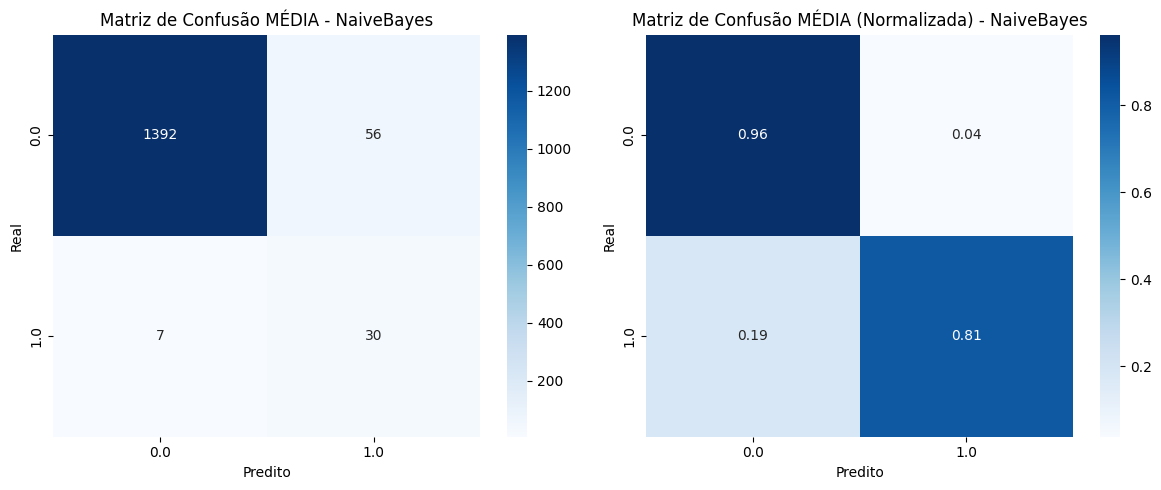

Folds LogisticRegression:   0%|          | 0/5 [00:00<?, ?it/s]

LogisticRegression | fold=fold_1 | Accuracy=0.982 | Precision=0.822 | Recall=0.760 | F1=0.788 | BalancedAccuracy=0.760 | GMean=0.724 | GMeanMicro=0.982 | AUPRC=0.707
LogisticRegression | fold=fold_2 | Accuracy=0.981 | Precision=0.811 | Recall=0.760 | F1=0.783 | BalancedAccuracy=0.760 | GMean=0.724 | GMeanMicro=0.981 | AUPRC=0.573
LogisticRegression | fold=fold_3 | Accuracy=0.982 | Precision=0.868 | Recall=0.707 | F1=0.763 | BalancedAccuracy=0.707 | GMean=0.644 | GMeanMicro=0.982 | AUPRC=0.650
LogisticRegression | fold=fold_4 | Accuracy=0.984 | Precision=0.874 | Recall=0.755 | F1=0.802 | BalancedAccuracy=0.755 | GMean=0.715 | GMeanMicro=0.984 | AUPRC=0.694
LogisticRegression | fold=fold_5 | Accuracy=0.985 | Precision=0.894 | Recall=0.769 | F1=0.819 | BalancedAccuracy=0.769 | GMean=0.734 | GMeanMicro=0.985 | AUPRC=0.667


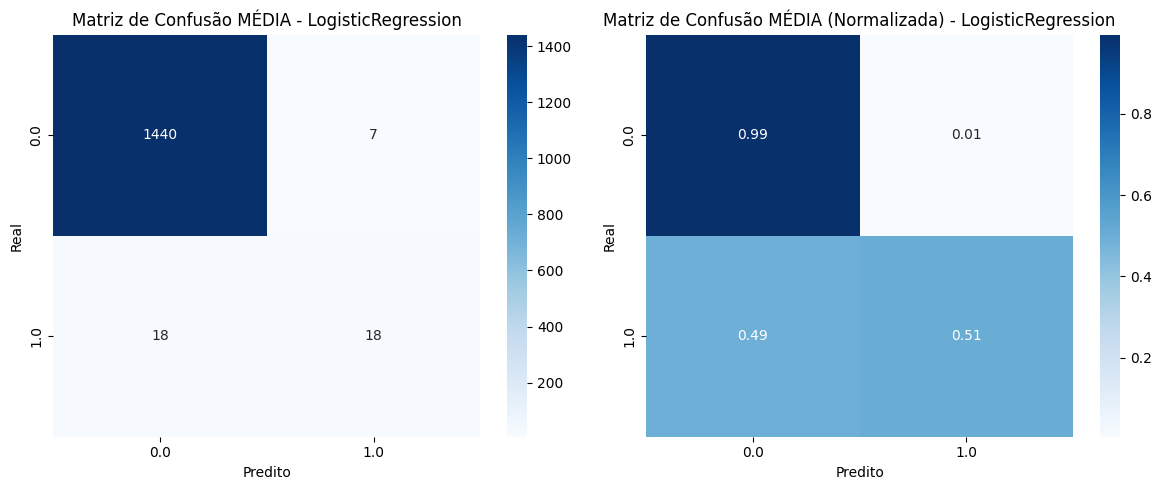

Folds LightGBM:   0%|          | 0/5 [00:00<?, ?it/s]

LightGBM | fold=fold_1 | Accuracy=0.985 | Precision=0.919 | Recall=0.735 | F1=0.800 | BalancedAccuracy=0.735 | GMean=0.686 | GMeanMicro=0.985 | AUPRC=0.673
LightGBM | fold=fold_2 | Accuracy=0.986 | Precision=0.907 | Recall=0.763 | F1=0.818 | BalancedAccuracy=0.763 | GMean=0.725 | GMeanMicro=0.986 | AUPRC=0.622
LightGBM | fold=fold_3 | Accuracy=0.979 | Precision=0.854 | Recall=0.610 | F1=0.665 | BalancedAccuracy=0.610 | GMean=0.471 | GMeanMicro=0.979 | AUPRC=0.622
LightGBM | fold=fold_4 | Accuracy=0.983 | Precision=0.893 | Recall=0.715 | F1=0.776 | BalancedAccuracy=0.715 | GMean=0.657 | GMeanMicro=0.983 | AUPRC=0.597
LightGBM | fold=fold_5 | Accuracy=0.983 | Precision=0.880 | Recall=0.728 | F1=0.784 | BalancedAccuracy=0.728 | GMean=0.677 | GMeanMicro=0.983 | AUPRC=0.672


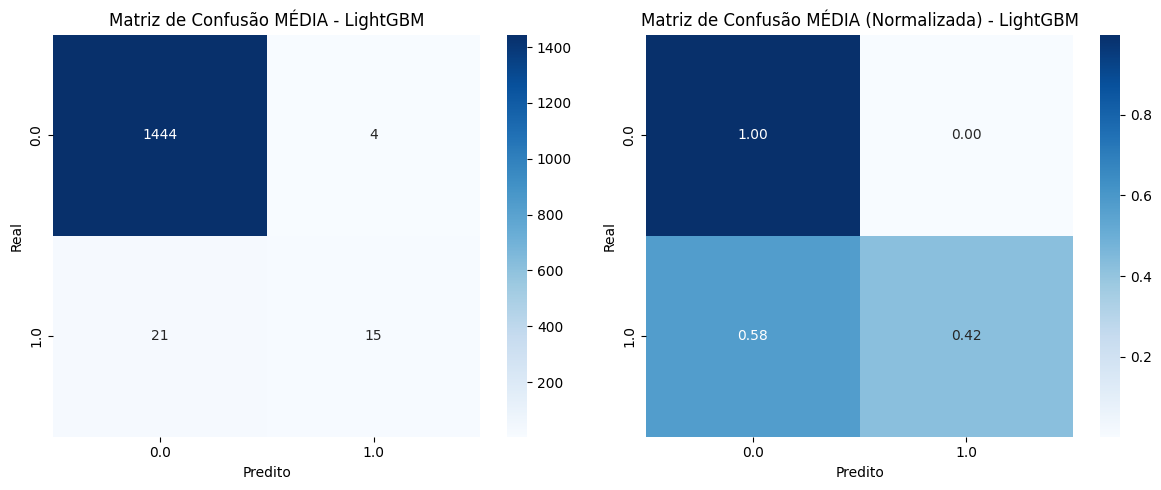

,Modelo,Accuracy,Precision,Recall,F1,BalancedAccuracy,GMean,GMeanMicro,AUPRC
0,NaiveBayes,0.96 (0.95-0.97) ± 0.01,0.67 (0.65-0.70) ± 0.02,0.89 (0.84-0.92) ± 0.03,0.73 (0.70-0.76) ± 0.02,0.89 (0.84-0.92) ± 0.03,0.88 (0.84-0.92) ± 0.03,0.96 (0.95-0.97) ± 0.01,0.70 (0.64-0.77) ± 0.05
1,LogisticRegression,0.98 (0.98-0.99) ± 0.00,0.85 (0.81-0.89) ± 0.04,0.75 (0.71-0.77) ± 0.02,0.79 (0.76-0.82) ± 0.02,0.75 (0.71-0.77) ± 0.02,0.71 (0.64-0.73) ± 0.04,0.98 (0.98-0.99) ± 0.00,0.66 (0.57-0.71) ± 0.05
2,LightGBM,0.98 (0.98-0.99) ± 0.00,0.89 (0.85-0.92) ± 0.03,0.71 (0.61-0.76) ± 0.06,0.77 (0.66-0.82) ± 0.06,0.71 (0.61-0.76) ± 0.06,0.64 (0.47-0.73) ± 0.10,0.98 (0.98-0.99) ± 0.00,0.64 (0.60-0.67) ± 0.03


In [7]:
_, metrics_cv_stop = evaluate_models(df_train_val, seed=seed, use_class_weight=True, log_each_fold=True)

display(metrics_cv_stop)

### Avaliação no conjunto de teste (somente remoção de stopwords)

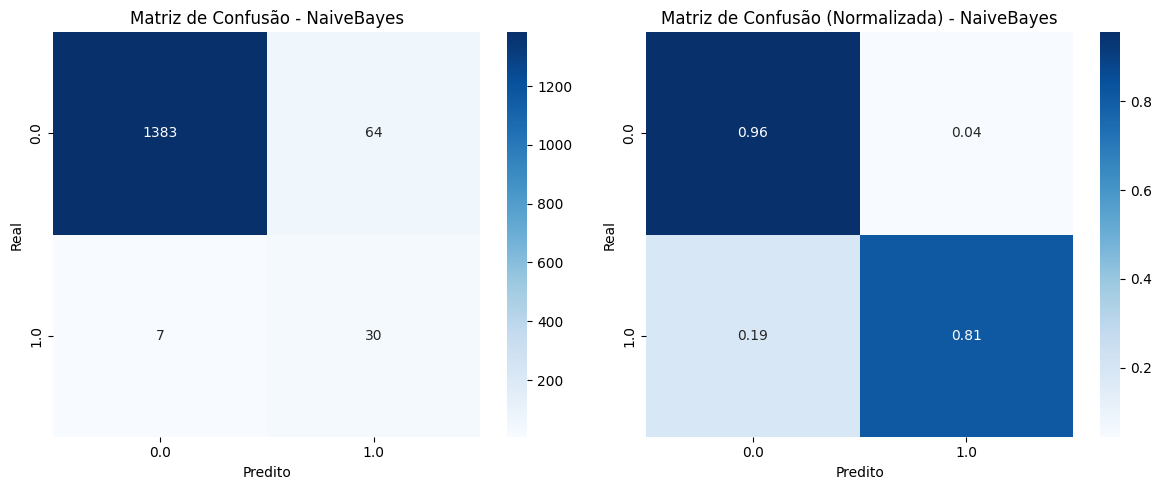

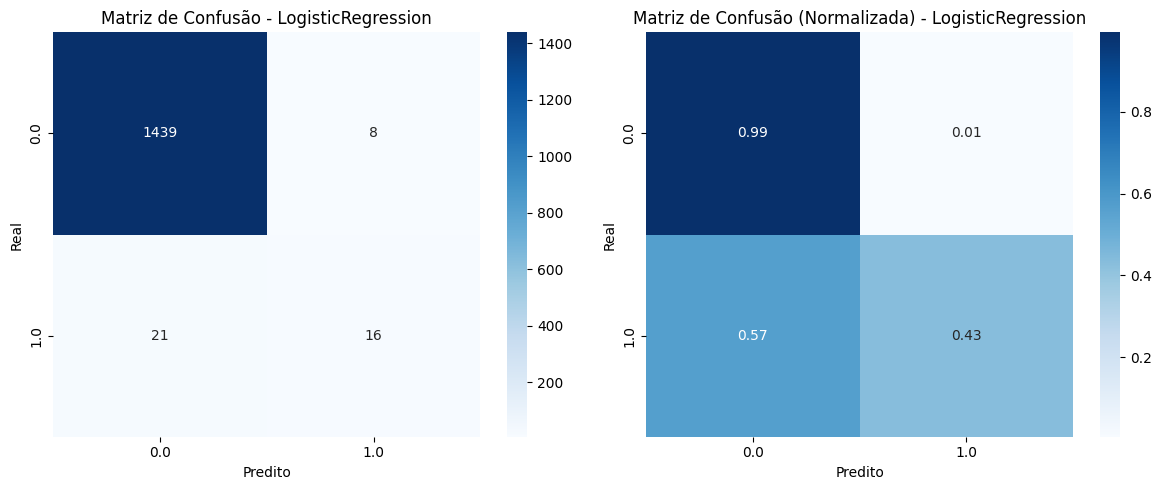

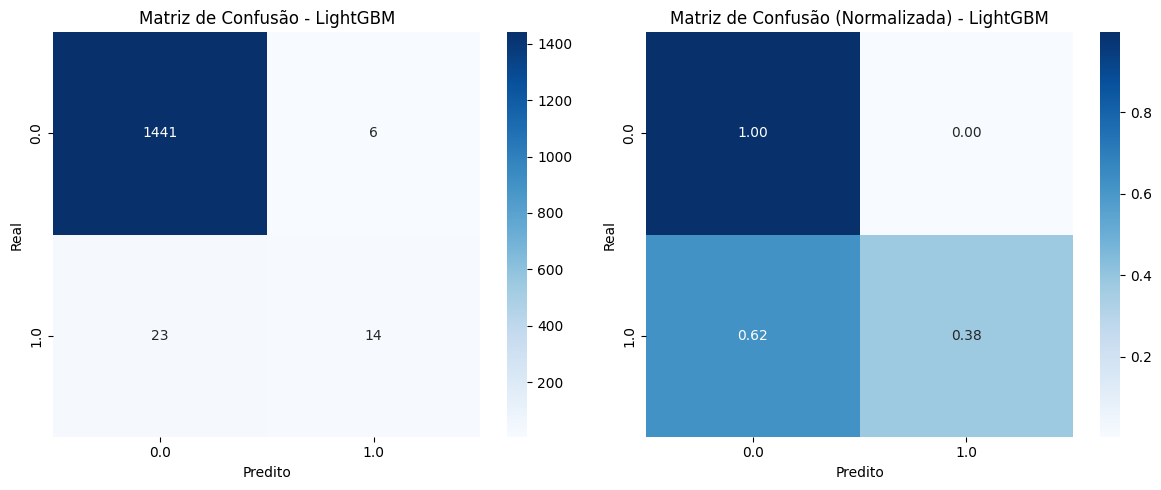

,Modelo,Accuracy,Precision,Recall,F1,BalancedAccuracy,GMean,GMeanMicro,AUPRC
0,NaiveBayes,0.95,0.66,0.88,0.72,0.88,0.88,0.95,0.63
1,LogisticRegression,0.98,0.83,0.71,0.76,0.71,0.66,0.98,0.57
2,LightGBM,0.98,0.84,0.69,0.74,0.69,0.61,0.98,0.54


In [8]:
metrics_test_stop = evaluate_on_test(df_train_val, df_test, seed=seed, use_class_weight=True)

display(metrics_test_stop)

# Only Lemmatizer influence

In [9]:
df["text"] = df["text_raw"].progress_apply(lambda x: preprocess_text(x, 
                                                                     remove_stopwords=False,
                                                                     lemmatize=True))
df.head(2)

  0%|          | 0/8904 [00:00<?, ?it/s]

,fold,label,text_raw,text
id,,,,
620,fold_3,0.0,"Animal Farm. \n Old Major, the old boar on th...",animal farm old major the old boar the manor f...
843,fold_2,0.0,"A Clockwork Orange. \n Alex, a teenager livin...",clockwork orange alex teenager live near futur...


In [10]:
# Split train test
df_test, df_train_val = get_train_test_by_total_with_folds(df)

# Novo número de features
show_number_of_features(df_train_val, column='text')

Tamanho do novo vocabulário: 70401


### Validação cruzada (somente lematização)

Folds NaiveBayes:   0%|          | 0/5 [00:00<?, ?it/s]

NaiveBayes | fold=fold_1 | Accuracy=0.949 | Precision=0.650 | Recall=0.906 | F1=0.711 | BalancedAccuracy=0.906 | GMean=0.905 | GMeanMicro=0.949 | AUPRC=0.756
NaiveBayes | fold=fold_2 | Accuracy=0.951 | Precision=0.652 | Recall=0.880 | F1=0.710 | BalancedAccuracy=0.880 | GMean=0.877 | GMeanMicro=0.951 | AUPRC=0.650
NaiveBayes | fold=fold_3 | Accuracy=0.960 | Precision=0.672 | Recall=0.871 | F1=0.731 | BalancedAccuracy=0.871 | GMean=0.866 | GMeanMicro=0.960 | AUPRC=0.683
NaiveBayes | fold=fold_4 | Accuracy=0.943 | Precision=0.630 | Recall=0.839 | F1=0.681 | BalancedAccuracy=0.839 | GMean=0.832 | GMeanMicro=0.943 | AUPRC=0.650
NaiveBayes | fold=fold_5 | Accuracy=0.949 | Precision=0.651 | Recall=0.882 | F1=0.709 | BalancedAccuracy=0.882 | GMean=0.879 | GMeanMicro=0.949 | AUPRC=0.671


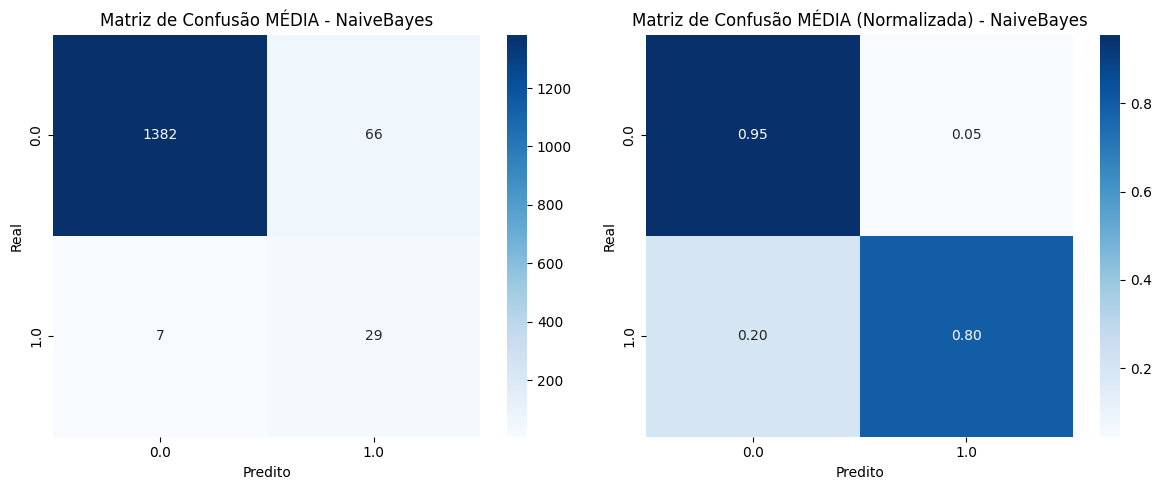

Folds LogisticRegression:   0%|          | 0/5 [00:00<?, ?it/s]

LogisticRegression | fold=fold_1 | Accuracy=0.986 | Precision=0.860 | Recall=0.830 | F1=0.844 | BalancedAccuracy=0.830 | GMean=0.814 | GMeanMicro=0.986 | AUPRC=0.756
LogisticRegression | fold=fold_2 | Accuracy=0.980 | Precision=0.789 | Recall=0.773 | F1=0.781 | BalancedAccuracy=0.773 | GMean=0.742 | GMeanMicro=0.980 | AUPRC=0.651
LogisticRegression | fold=fold_3 | Accuracy=0.986 | Precision=0.884 | Recall=0.790 | F1=0.830 | BalancedAccuracy=0.790 | GMean=0.762 | GMeanMicro=0.986 | AUPRC=0.711
LogisticRegression | fold=fold_4 | Accuracy=0.980 | Precision=0.800 | Recall=0.753 | F1=0.774 | BalancedAccuracy=0.753 | GMean=0.714 | GMeanMicro=0.980 | AUPRC=0.705
LogisticRegression | fold=fold_5 | Accuracy=0.981 | Precision=0.809 | Recall=0.793 | F1=0.801 | BalancedAccuracy=0.793 | GMean=0.768 | GMeanMicro=0.981 | AUPRC=0.656


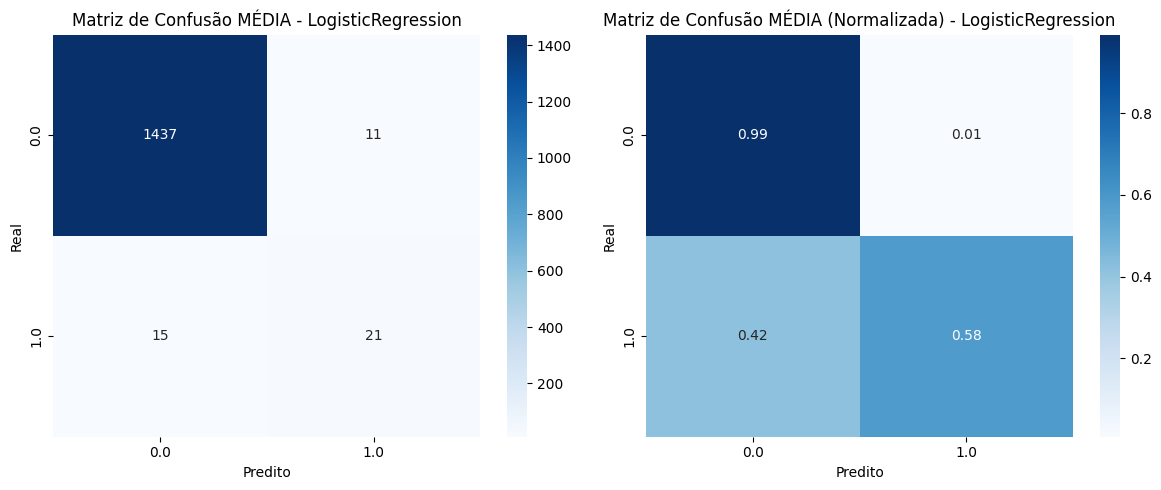

Folds LightGBM:   0%|          | 0/5 [00:00<?, ?it/s]

LightGBM | fold=fold_1 | Accuracy=0.986 | Precision=0.895 | Recall=0.776 | F1=0.824 | BalancedAccuracy=0.776 | GMean=0.744 | GMeanMicro=0.986 | AUPRC=0.674
LightGBM | fold=fold_2 | Accuracy=0.987 | Precision=0.915 | Recall=0.790 | F1=0.841 | BalancedAccuracy=0.790 | GMean=0.763 | GMeanMicro=0.987 | AUPRC=0.738
LightGBM | fold=fold_3 | Accuracy=0.985 | Precision=0.898 | Recall=0.735 | F1=0.794 | BalancedAccuracy=0.735 | GMean=0.686 | GMeanMicro=0.985 | AUPRC=0.722
LightGBM | fold=fold_4 | Accuracy=0.981 | Precision=0.874 | Recall=0.674 | F1=0.736 | BalancedAccuracy=0.674 | GMean=0.592 | GMeanMicro=0.981 | AUPRC=0.619
LightGBM | fold=fold_5 | Accuracy=0.981 | Precision=0.850 | Recall=0.701 | F1=0.754 | BalancedAccuracy=0.701 | GMean=0.635 | GMeanMicro=0.981 | AUPRC=0.613


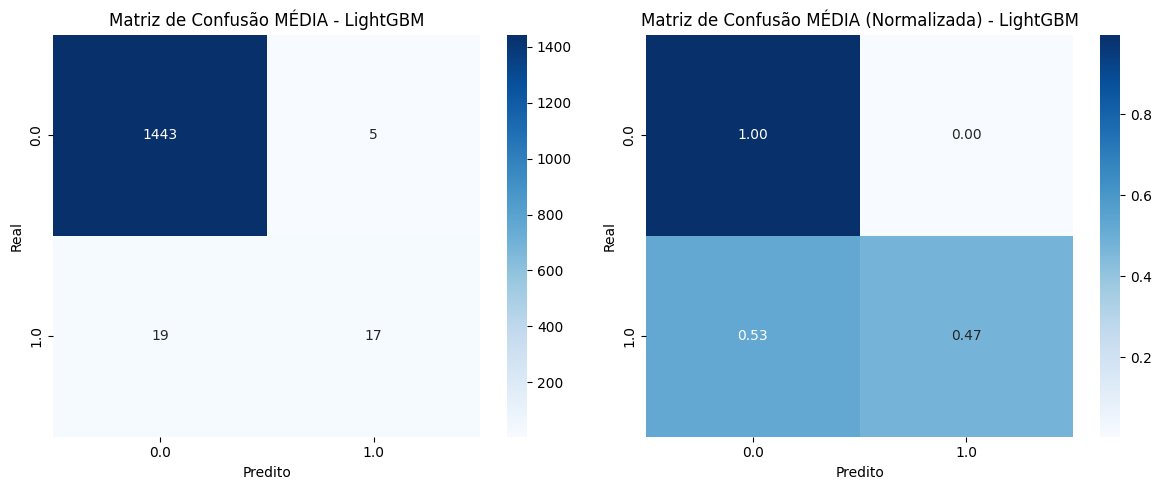

,Modelo,Accuracy,Precision,Recall,F1,BalancedAccuracy,GMean,GMeanMicro,AUPRC
0,NaiveBayes,0.95 (0.94-0.96) ± 0.01,0.65 (0.63-0.67) ± 0.01,0.88 (0.84-0.91) ± 0.02,0.71 (0.68-0.73) ± 0.02,0.88 (0.84-0.91) ± 0.02,0.87 (0.83-0.90) ± 0.03,0.95 (0.94-0.96) ± 0.01,0.68 (0.65-0.76) ± 0.04
1,LogisticRegression,0.98 (0.98-0.99) ± 0.00,0.83 (0.79-0.88) ± 0.04,0.79 (0.75-0.83) ± 0.03,0.81 (0.77-0.84) ± 0.03,0.79 (0.75-0.83) ± 0.03,0.76 (0.71-0.81) ± 0.04,0.98 (0.98-0.99) ± 0.00,0.70 (0.65-0.76) ± 0.04
2,LightGBM,0.98 (0.98-0.99) ± 0.00,0.89 (0.85-0.91) ± 0.03,0.74 (0.67-0.79) ± 0.05,0.79 (0.74-0.84) ± 0.04,0.74 (0.67-0.79) ± 0.05,0.68 (0.59-0.76) ± 0.07,0.98 (0.98-0.99) ± 0.00,0.67 (0.61-0.74) ± 0.06


In [11]:
_, metrics_cv_lemma = evaluate_models(df_train_val, seed=seed, use_class_weight=True, log_each_fold=True)

display(metrics_cv_lemma)

### Avaliação no conjunto de teste (somente lematização)

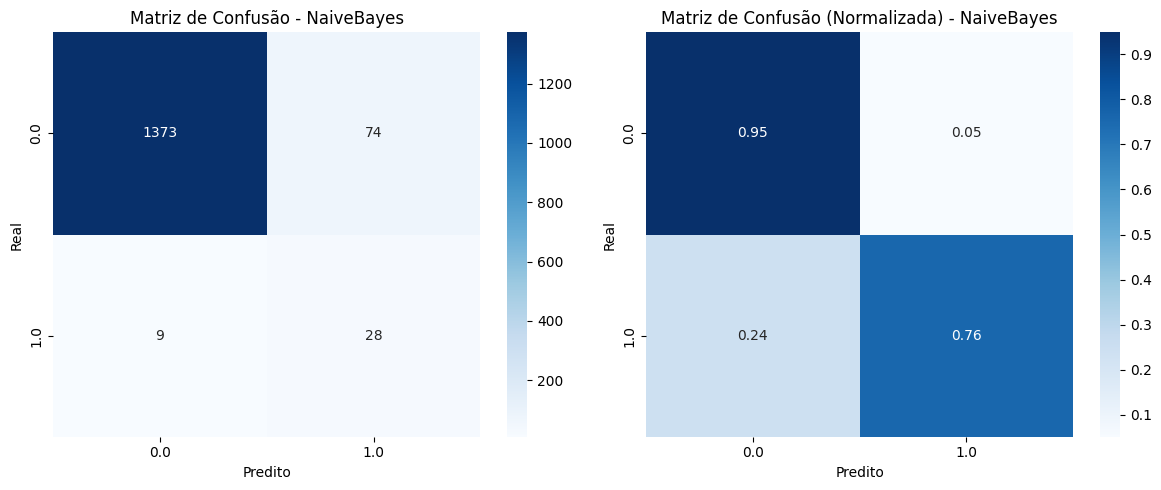

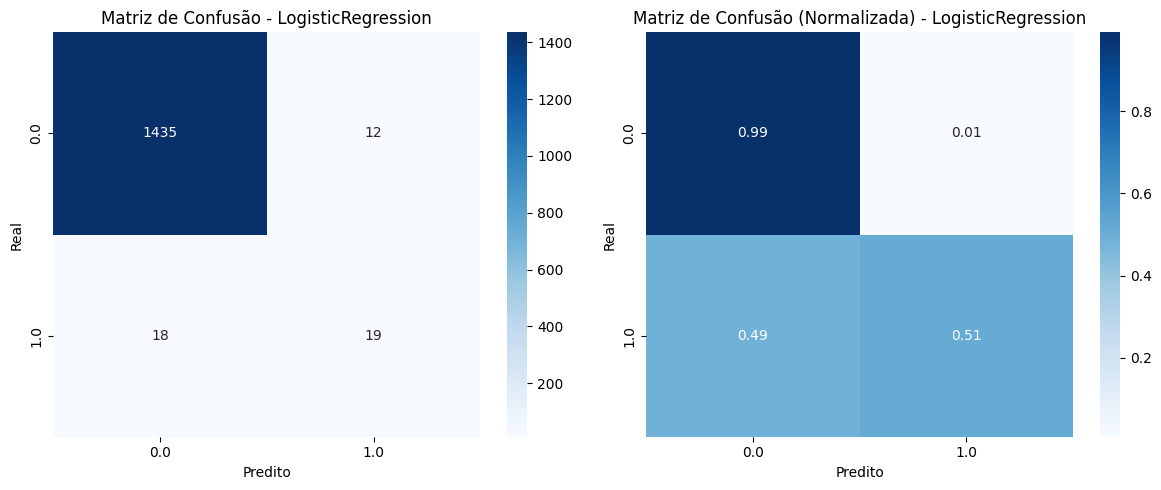

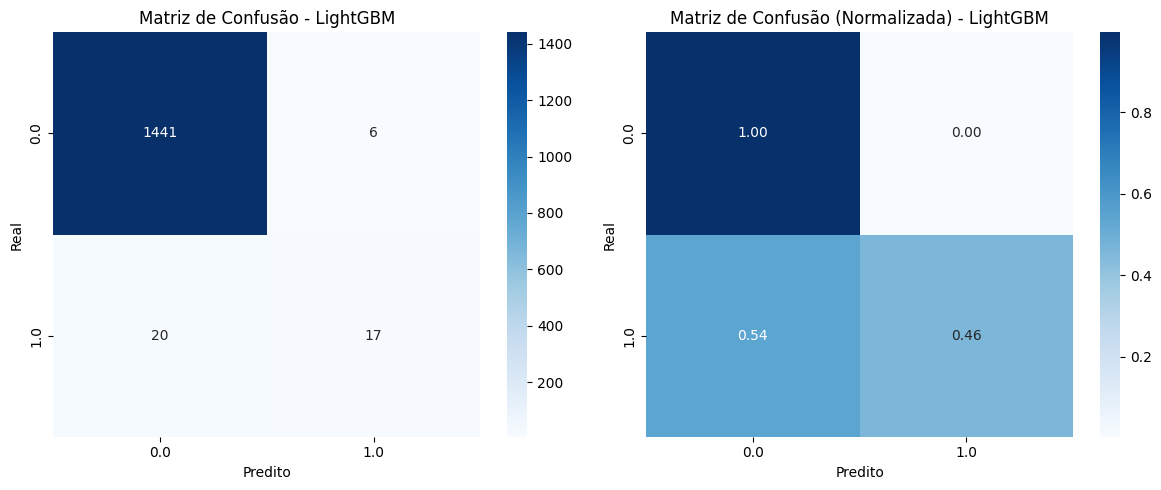

,Modelo,Accuracy,Precision,Recall,F1,BalancedAccuracy,GMean,GMeanMicro,AUPRC
0,NaiveBayes,0.94,0.63,0.85,0.69,0.85,0.85,0.94,0.56
1,LogisticRegression,0.98,0.80,0.75,0.77,0.75,0.71,0.98,0.60
2,LightGBM,0.98,0.86,0.73,0.78,0.73,0.68,0.98,0.62


In [12]:
metrics_test_lemma = evaluate_on_test(df_train_val, df_test, seed=seed, use_class_weight=True)

display(metrics_test_lemma)

# Influência da lematizaçao e remoção conjunta de stopwords

In [13]:
df["text"] = df["text_raw"].progress_apply(lambda x: preprocess_text(x, 
                                                                     remove_stopwords=True,
                                                                     lemmatize=True))
df.head(2)

  0%|          | 0/8904 [00:00<?, ?it/s]

,fold,label,text_raw,text
id,,,,
620,fold_3,0.0,"Animal Farm. \n Old Major, the old boar on th...",animal farm old major old boar manor farm call...
843,fold_2,0.0,"A Clockwork Orange. \n Alex, a teenager livin...",clockwork orange alex teenager live near futur...


In [14]:
# Split train test
df_test, df_train_val = get_train_test_by_total_with_folds(df)

# Novo número de features
show_number_of_features(df_train_val, column='text')

Tamanho do novo vocabulário: 70234


### Validação cruzada (lematização e remoção de stopwords)

Folds NaiveBayes:   0%|          | 0/5 [00:00<?, ?it/s]

NaiveBayes | fold=fold_1 | Accuracy=0.948 | Precision=0.649 | Recall=0.906 | F1=0.709 | BalancedAccuracy=0.906 | GMean=0.905 | GMeanMicro=0.948 | AUPRC=0.735
NaiveBayes | fold=fold_2 | Accuracy=0.951 | Precision=0.655 | Recall=0.907 | F1=0.717 | BalancedAccuracy=0.907 | GMean=0.906 | GMeanMicro=0.951 | AUPRC=0.627
NaiveBayes | fold=fold_3 | Accuracy=0.961 | Precision=0.677 | Recall=0.872 | F1=0.735 | BalancedAccuracy=0.872 | GMean=0.867 | GMeanMicro=0.961 | AUPRC=0.670
NaiveBayes | fold=fold_4 | Accuracy=0.944 | Precision=0.631 | Recall=0.840 | F1=0.682 | BalancedAccuracy=0.840 | GMean=0.832 | GMeanMicro=0.944 | AUPRC=0.638
NaiveBayes | fold=fold_5 | Accuracy=0.951 | Precision=0.654 | Recall=0.883 | F1=0.713 | BalancedAccuracy=0.883 | GMean=0.880 | GMeanMicro=0.951 | AUPRC=0.670


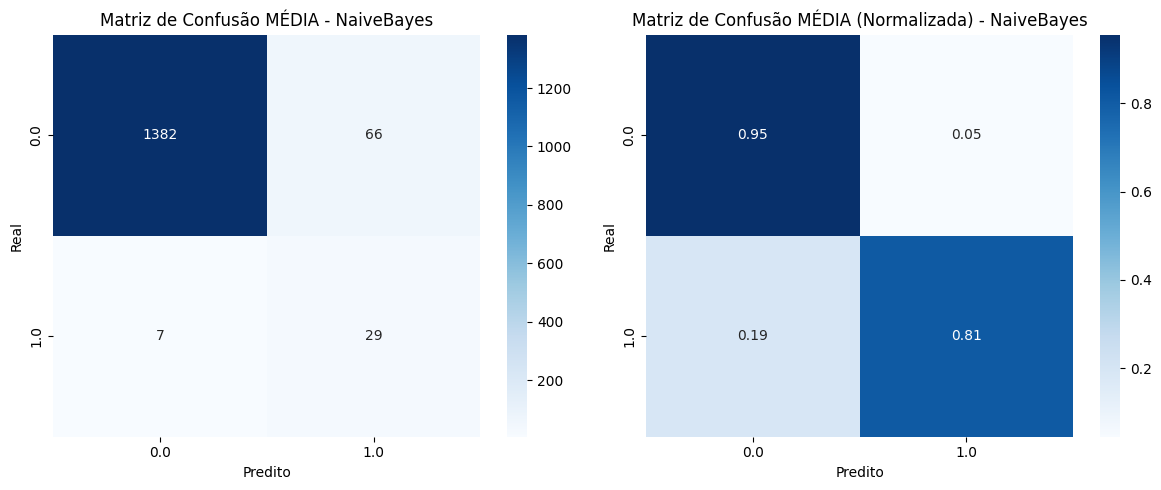

Folds LogisticRegression:   0%|          | 0/5 [00:00<?, ?it/s]

LogisticRegression | fold=fold_1 | Accuracy=0.982 | Precision=0.823 | Recall=0.788 | F1=0.804 | BalancedAccuracy=0.788 | GMean=0.761 | GMeanMicro=0.982 | AUPRC=0.687
LogisticRegression | fold=fold_2 | Accuracy=0.979 | Precision=0.782 | Recall=0.759 | F1=0.770 | BalancedAccuracy=0.759 | GMean=0.723 | GMeanMicro=0.979 | AUPRC=0.593
LogisticRegression | fold=fold_3 | Accuracy=0.985 | Precision=0.890 | Recall=0.762 | F1=0.813 | BalancedAccuracy=0.762 | GMean=0.725 | GMeanMicro=0.985 | AUPRC=0.688
LogisticRegression | fold=fold_4 | Accuracy=0.980 | Precision=0.810 | Recall=0.753 | F1=0.779 | BalancedAccuracy=0.753 | GMean=0.714 | GMeanMicro=0.980 | AUPRC=0.665
LogisticRegression | fold=fold_5 | Accuracy=0.985 | Precision=0.874 | Recall=0.795 | F1=0.830 | BalancedAccuracy=0.795 | GMean=0.769 | GMeanMicro=0.985 | AUPRC=0.648


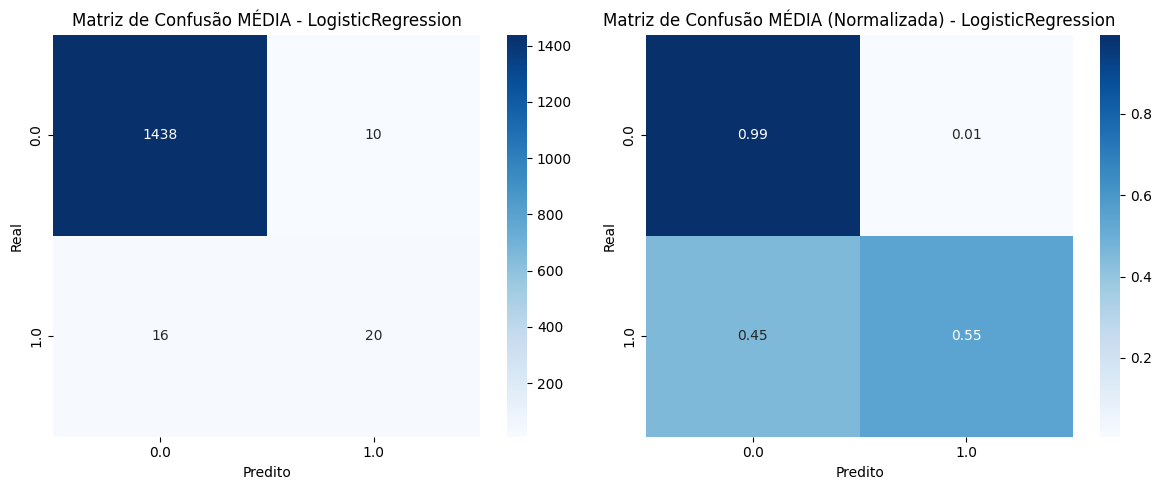

Folds LightGBM:   0%|          | 0/5 [00:00<?, ?it/s]

LightGBM | fold=fold_1 | Accuracy=0.984 | Precision=0.893 | Recall=0.721 | F1=0.782 | BalancedAccuracy=0.721 | GMean=0.666 | GMeanMicro=0.984 | AUPRC=0.668
LightGBM | fold=fold_2 | Accuracy=0.985 | Precision=0.890 | Recall=0.762 | F1=0.813 | BalancedAccuracy=0.762 | GMean=0.725 | GMeanMicro=0.985 | AUPRC=0.646
LightGBM | fold=fold_3 | Accuracy=0.988 | Precision=0.949 | Recall=0.777 | F1=0.842 | BalancedAccuracy=0.777 | GMean=0.745 | GMeanMicro=0.988 | AUPRC=0.743
LightGBM | fold=fold_4 | Accuracy=0.982 | Precision=0.853 | Recall=0.741 | F1=0.786 | BalancedAccuracy=0.741 | GMean=0.696 | GMeanMicro=0.982 | AUPRC=0.650
LightGBM | fold=fold_5 | Accuracy=0.978 | Precision=0.801 | Recall=0.673 | F1=0.719 | BalancedAccuracy=0.673 | GMean=0.591 | GMeanMicro=0.978 | AUPRC=0.620


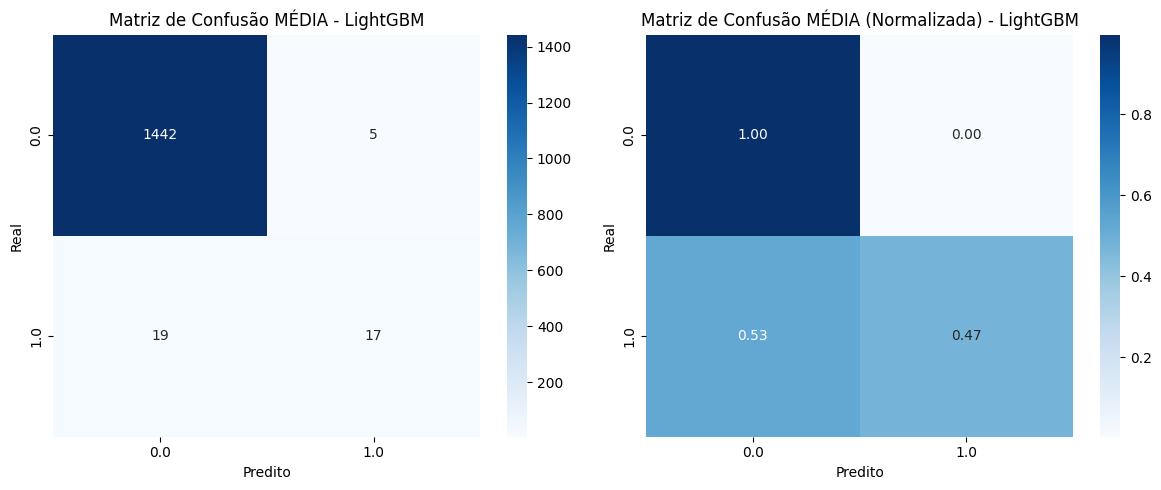

,Modelo,Accuracy,Precision,Recall,F1,BalancedAccuracy,GMean,GMeanMicro,AUPRC
0,NaiveBayes,0.95 (0.94-0.96) ± 0.01,0.65 (0.63-0.68) ± 0.02,0.88 (0.84-0.91) ± 0.03,0.71 (0.68-0.74) ± 0.02,0.88 (0.84-0.91) ± 0.03,0.88 (0.83-0.91) ± 0.03,0.95 (0.94-0.96) ± 0.01,0.67 (0.63-0.73) ± 0.04
1,LogisticRegression,0.98 (0.98-0.99) ± 0.00,0.84 (0.78-0.89) ± 0.05,0.77 (0.75-0.79) ± 0.02,0.80 (0.77-0.83) ± 0.02,0.77 (0.75-0.79) ± 0.02,0.74 (0.71-0.77) ± 0.02,0.98 (0.98-0.99) ± 0.00,0.66 (0.59-0.69) ± 0.04
2,LightGBM,0.98 (0.98-0.99) ± 0.00,0.88 (0.80-0.95) ± 0.05,0.73 (0.67-0.78) ± 0.04,0.79 (0.72-0.84) ± 0.05,0.73 (0.67-0.78) ± 0.04,0.68 (0.59-0.74) ± 0.06,0.98 (0.98-0.99) ± 0.00,0.67 (0.62-0.74) ± 0.05


In [15]:
_, metrics_cv_lemma_stop = evaluate_models(df_train_val, seed=seed, use_class_weight=True, log_each_fold=True)

display(metrics_cv_lemma_stop)

### Avaliação no conjunto de teste (lematização e remoção de stopwords)

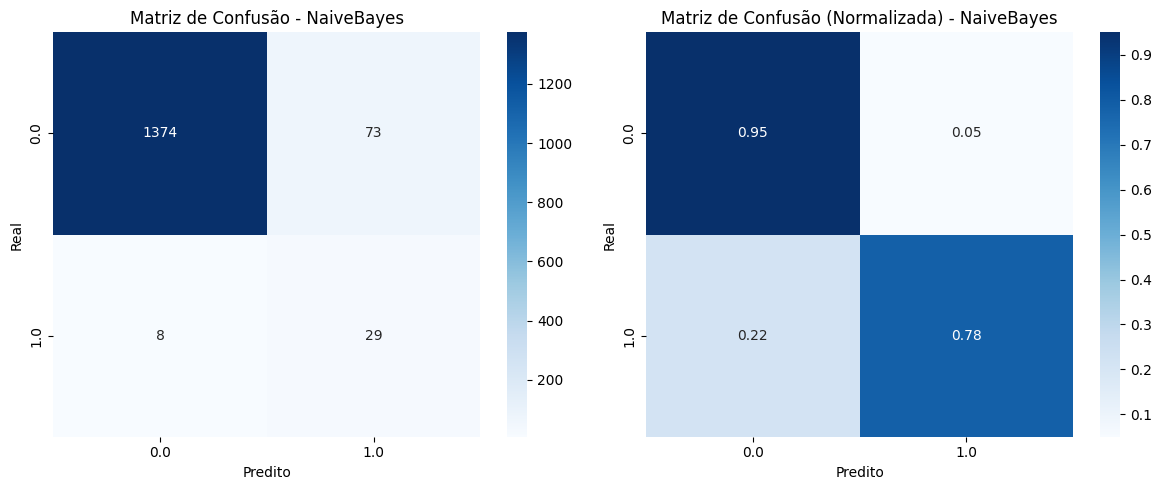

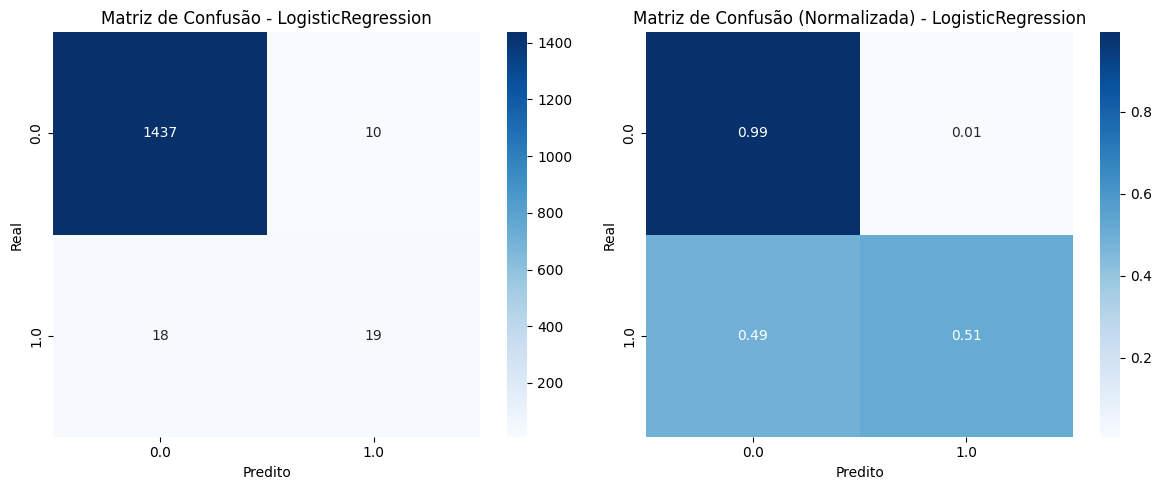

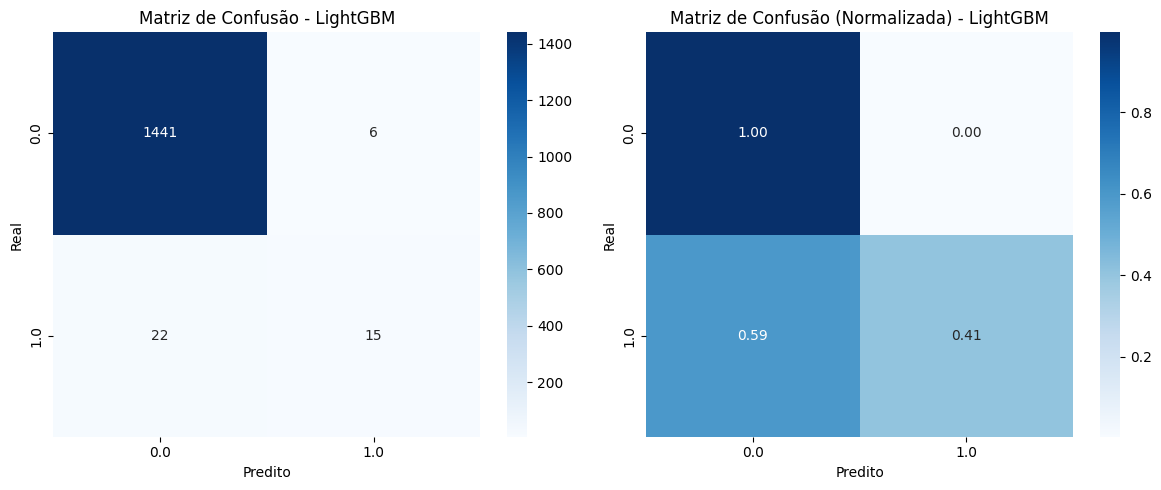

,Modelo,Accuracy,Precision,Recall,F1,BalancedAccuracy,GMean,GMeanMicro,AUPRC
0,NaiveBayes,0.95,0.64,0.87,0.69,0.87,0.86,0.95,0.56
1,LogisticRegression,0.98,0.82,0.75,0.78,0.75,0.71,0.98,0.60
2,LightGBM,0.98,0.85,0.70,0.75,0.70,0.64,0.98,0.60


In [16]:
metrics_test_lemma_stop = evaluate_on_test(df_train_val, df_test, seed=seed, use_class_weight=True)

display(metrics_test_lemma_stop)

# Comparação entre as estratégias e a baseline
## CV

In [17]:
path_baseline_results = '../results/baseline'
metrics_cv_baseline = pd.read_csv(f'{path_baseline_results}/cv_baseline.csv')
metrics_test_baseline = pd.read_csv(f'{path_baseline_results}/test_baseline.csv')

results_cv = {
    'stop': metrics_cv_stop,
    'lemma': metrics_cv_lemma,
    'lemma_stop': metrics_cv_lemma_stop,
    'baseline': metrics_cv_baseline
}

results_test = {
    'stop': metrics_test_stop,
    'lemma': metrics_test_lemma,
    'lemma_stop': metrics_test_lemma_stop,
    'baseline': metrics_test_baseline
}

print('Show cv results')
for type, metric in results_cv.items():
    print(type)
    display(metric)

Show cv results
stop


,Modelo,Accuracy,Precision,Recall,F1,BalancedAccuracy,GMean,GMeanMicro,AUPRC
0,NaiveBayes,0.96 (0.95-0.97) ± 0.01,0.67 (0.65-0.70) ± 0.02,0.89 (0.84-0.92) ± 0.03,0.73 (0.70-0.76) ± 0.02,0.89 (0.84-0.92) ± 0.03,0.88 (0.84-0.92) ± 0.03,0.96 (0.95-0.97) ± 0.01,0.70 (0.64-0.77) ± 0.05
1,LogisticRegression,0.98 (0.98-0.99) ± 0.00,0.85 (0.81-0.89) ± 0.04,0.75 (0.71-0.77) ± 0.02,0.79 (0.76-0.82) ± 0.02,0.75 (0.71-0.77) ± 0.02,0.71 (0.64-0.73) ± 0.04,0.98 (0.98-0.99) ± 0.00,0.66 (0.57-0.71) ± 0.05
2,LightGBM,0.98 (0.98-0.99) ± 0.00,0.89 (0.85-0.92) ± 0.03,0.71 (0.61-0.76) ± 0.06,0.77 (0.66-0.82) ± 0.06,0.71 (0.61-0.76) ± 0.06,0.64 (0.47-0.73) ± 0.10,0.98 (0.98-0.99) ± 0.00,0.64 (0.60-0.67) ± 0.03


lemma


,Modelo,Accuracy,Precision,Recall,F1,BalancedAccuracy,GMean,GMeanMicro,AUPRC
0,NaiveBayes,0.95 (0.94-0.96) ± 0.01,0.65 (0.63-0.67) ± 0.01,0.88 (0.84-0.91) ± 0.02,0.71 (0.68-0.73) ± 0.02,0.88 (0.84-0.91) ± 0.02,0.87 (0.83-0.90) ± 0.03,0.95 (0.94-0.96) ± 0.01,0.68 (0.65-0.76) ± 0.04
1,LogisticRegression,0.98 (0.98-0.99) ± 0.00,0.83 (0.79-0.88) ± 0.04,0.79 (0.75-0.83) ± 0.03,0.81 (0.77-0.84) ± 0.03,0.79 (0.75-0.83) ± 0.03,0.76 (0.71-0.81) ± 0.04,0.98 (0.98-0.99) ± 0.00,0.70 (0.65-0.76) ± 0.04
2,LightGBM,0.98 (0.98-0.99) ± 0.00,0.89 (0.85-0.91) ± 0.03,0.74 (0.67-0.79) ± 0.05,0.79 (0.74-0.84) ± 0.04,0.74 (0.67-0.79) ± 0.05,0.68 (0.59-0.76) ± 0.07,0.98 (0.98-0.99) ± 0.00,0.67 (0.61-0.74) ± 0.06


lemma_stop


,Modelo,Accuracy,Precision,Recall,F1,BalancedAccuracy,GMean,GMeanMicro,AUPRC
0,NaiveBayes,0.95 (0.94-0.96) ± 0.01,0.65 (0.63-0.68) ± 0.02,0.88 (0.84-0.91) ± 0.03,0.71 (0.68-0.74) ± 0.02,0.88 (0.84-0.91) ± 0.03,0.88 (0.83-0.91) ± 0.03,0.95 (0.94-0.96) ± 0.01,0.67 (0.63-0.73) ± 0.04
1,LogisticRegression,0.98 (0.98-0.99) ± 0.00,0.84 (0.78-0.89) ± 0.05,0.77 (0.75-0.79) ± 0.02,0.80 (0.77-0.83) ± 0.02,0.77 (0.75-0.79) ± 0.02,0.74 (0.71-0.77) ± 0.02,0.98 (0.98-0.99) ± 0.00,0.66 (0.59-0.69) ± 0.04
2,LightGBM,0.98 (0.98-0.99) ± 0.00,0.88 (0.80-0.95) ± 0.05,0.73 (0.67-0.78) ± 0.04,0.79 (0.72-0.84) ± 0.05,0.73 (0.67-0.78) ± 0.04,0.68 (0.59-0.74) ± 0.06,0.98 (0.98-0.99) ± 0.00,0.67 (0.62-0.74) ± 0.05


baseline


,Modelo,Accuracy,Precision,Recall,F1,BalancedAccuracy,GMean,GMeanMicro,AUPRC
0,NaiveBayes,0.96 (0.95-0.97) ± 0.01,0.68 (0.65-0.70) ± 0.02,0.90 (0.84-0.94) ± 0.04,0.74 (0.70-0.77) ± 0.02,0.90 (0.84-0.94) ± 0.04,0.89 (0.84-0.94) ± 0.04,0.96 (0.95-0.97) ± 0.01,0.73 (0.68-0.81) ± 0.05
1,LogisticRegression,0.99 (0.98-0.99) ± 0.00,0.86 (0.83-0.89) ± 0.02,0.83 (0.80-0.88) ± 0.03,0.84 (0.82-0.88) ± 0.03,0.83 (0.80-0.88) ± 0.03,0.82 (0.78-0.87) ± 0.04,0.99 (0.98-0.99) ± 0.00,0.73 (0.68-0.79) ± 0.05
2,LightGBM,0.98 (0.98-0.98) ± 0.00,0.90 (0.83-0.95) ± 0.04,0.69 (0.67-0.73) ± 0.03,0.76 (0.73-0.79) ± 0.03,0.69 (0.67-0.73) ± 0.03,0.62 (0.58-0.69) ± 0.04,0.98 (0.98-0.98) ± 0.00,0.63 (0.59-0.65) ± 0.03


## Teste

In [18]:
print('Show test results')
for type, metric in results_test.items():
    print(type)
    display(metric)

Show test results
stop


,Modelo,Accuracy,Precision,Recall,F1,BalancedAccuracy,GMean,GMeanMicro,AUPRC
0,NaiveBayes,0.95,0.66,0.88,0.72,0.88,0.88,0.95,0.63
1,LogisticRegression,0.98,0.83,0.71,0.76,0.71,0.66,0.98,0.57
2,LightGBM,0.98,0.84,0.69,0.74,0.69,0.61,0.98,0.54


lemma


,Modelo,Accuracy,Precision,Recall,F1,BalancedAccuracy,GMean,GMeanMicro,AUPRC
0,NaiveBayes,0.94,0.63,0.85,0.69,0.85,0.85,0.94,0.56
1,LogisticRegression,0.98,0.80,0.75,0.77,0.75,0.71,0.98,0.60
2,LightGBM,0.98,0.86,0.73,0.78,0.73,0.68,0.98,0.62


lemma_stop


,Modelo,Accuracy,Precision,Recall,F1,BalancedAccuracy,GMean,GMeanMicro,AUPRC
0,NaiveBayes,0.95,0.64,0.87,0.69,0.87,0.86,0.95,0.56
1,LogisticRegression,0.98,0.82,0.75,0.78,0.75,0.71,0.98,0.60
2,LightGBM,0.98,0.85,0.70,0.75,0.70,0.64,0.98,0.60


baseline


,Modelo,Accuracy,Precision,Recall,F1,BalancedAccuracy,GMean,GMeanMicro,AUPRC
0,NaiveBayes,0.96,0.68,0.90,0.74,0.90,0.90,0.96,0.64
1,LogisticRegression,0.99,0.87,0.82,0.84,0.82,0.80,0.99,0.64
2,LightGBM,0.98,0.89,0.70,0.76,0.70,0.64,0.98,0.61


In [19]:
show_results_by_model(results_cv, title="Cross-validation")
show_results_by_model(results_test, title="Test set")



=== Cross-validation: LightGBM ===


,Config,Modelo,Accuracy,Precision,Recall,F1,BalancedAccuracy,GMean,GMeanMicro,AUPRC
0,stop,LightGBM,0.98 (0.98-0.99) ± 0.00,0.89 (0.85-0.92) ± 0.03,0.71 (0.61-0.76) ± 0.06,0.77 (0.66-0.82) ± 0.06,0.71 (0.61-0.76) ± 0.06,0.64 (0.47-0.73) ± 0.10,0.98 (0.98-0.99) ± 0.00,0.64 (0.60-0.67) ± 0.03
1,lemma,LightGBM,0.98 (0.98-0.99) ± 0.00,0.89 (0.85-0.91) ± 0.03,0.74 (0.67-0.79) ± 0.05,0.79 (0.74-0.84) ± 0.04,0.74 (0.67-0.79) ± 0.05,0.68 (0.59-0.76) ± 0.07,0.98 (0.98-0.99) ± 0.00,0.67 (0.61-0.74) ± 0.06
2,lemma_stop,LightGBM,0.98 (0.98-0.99) ± 0.00,0.88 (0.80-0.95) ± 0.05,0.73 (0.67-0.78) ± 0.04,0.79 (0.72-0.84) ± 0.05,0.73 (0.67-0.78) ± 0.04,0.68 (0.59-0.74) ± 0.06,0.98 (0.98-0.99) ± 0.00,0.67 (0.62-0.74) ± 0.05
3,baseline,LightGBM,0.98 (0.98-0.98) ± 0.00,0.90 (0.83-0.95) ± 0.04,0.69 (0.67-0.73) ± 0.03,0.76 (0.73-0.79) ± 0.03,0.69 (0.67-0.73) ± 0.03,0.62 (0.58-0.69) ± 0.04,0.98 (0.98-0.98) ± 0.00,0.63 (0.59-0.65) ± 0.03



=== Cross-validation: LogisticRegression ===


,Config,Modelo,Accuracy,Precision,Recall,F1,BalancedAccuracy,GMean,GMeanMicro,AUPRC
0,stop,LogisticRegression,0.98 (0.98-0.99) ± 0.00,0.85 (0.81-0.89) ± 0.04,0.75 (0.71-0.77) ± 0.02,0.79 (0.76-0.82) ± 0.02,0.75 (0.71-0.77) ± 0.02,0.71 (0.64-0.73) ± 0.04,0.98 (0.98-0.99) ± 0.00,0.66 (0.57-0.71) ± 0.05
1,lemma,LogisticRegression,0.98 (0.98-0.99) ± 0.00,0.83 (0.79-0.88) ± 0.04,0.79 (0.75-0.83) ± 0.03,0.81 (0.77-0.84) ± 0.03,0.79 (0.75-0.83) ± 0.03,0.76 (0.71-0.81) ± 0.04,0.98 (0.98-0.99) ± 0.00,0.70 (0.65-0.76) ± 0.04
2,lemma_stop,LogisticRegression,0.98 (0.98-0.99) ± 0.00,0.84 (0.78-0.89) ± 0.05,0.77 (0.75-0.79) ± 0.02,0.80 (0.77-0.83) ± 0.02,0.77 (0.75-0.79) ± 0.02,0.74 (0.71-0.77) ± 0.02,0.98 (0.98-0.99) ± 0.00,0.66 (0.59-0.69) ± 0.04
3,baseline,LogisticRegression,0.99 (0.98-0.99) ± 0.00,0.86 (0.83-0.89) ± 0.02,0.83 (0.80-0.88) ± 0.03,0.84 (0.82-0.88) ± 0.03,0.83 (0.80-0.88) ± 0.03,0.82 (0.78-0.87) ± 0.04,0.99 (0.98-0.99) ± 0.00,0.73 (0.68-0.79) ± 0.05



=== Cross-validation: NaiveBayes ===


...

,Config,Modelo,Accuracy,Precision,Recall,F1,BalancedAccuracy,GMean,GMeanMicro,AUPRC
0,stop,LightGBM,0.98,0.84,0.69,0.74,0.69,0.61,0.98,0.54
1,lemma,LightGBM,0.98,0.86,0.73,0.78,0.73,0.68,0.98,0.62
2,lemma_stop,LightGBM,0.98,0.85,0.70,0.75,0.70,0.64,0.98,0.60
3,baseline,LightGBM,0.98,0.89,0.70,0.76,0.70,0.64,0.98,0.61



=== Test set: LogisticRegression ===


,Config,Modelo,Accuracy,Precision,Recall,F1,BalancedAccuracy,GMean,GMeanMicro,AUPRC
0,stop,LogisticRegression,0.98,0.83,0.71,0.76,0.71,0.66,0.98,0.57
1,lemma,LogisticRegression,0.98,0.80,0.75,0.77,0.75,0.71,0.98,0.60
2,lemma_stop,LogisticRegression,0.98,0.82,0.75,0.78,0.75,0.71,0.98,0.60
3,baseline,LogisticRegression,0.99,0.87,0.82,0.84,0.82,0.80,0.99,0.64



=== Test set: NaiveBayes ===


,Config,Modelo,Accuracy,Precision,Recall,F1,BalancedAccuracy,GMean,GMeanMicro,AUPRC
0,stop,NaiveBayes,0.95,0.66,0.88,0.72,0.88,0.88,0.95,0.63
1,lemma,NaiveBayes,0.94,0.63,0.85,0.69,0.85,0.85,0.94,0.56
2,lemma_stop,NaiveBayes,0.95,0.64,0.87,0.69,0.87,0.86,0.95,0.56
3,baseline,NaiveBayes,0.96,0.68,0.90,0.74,0.90,0.90,0.96,0.64


# Conclusão 
- Lembrando que F1, Recall e Precision são as medidas MACRO
- Na validação cruzada, dependendo da métrica, para o LightGBM nota-se uma melhoria (F1, Recall, GMEAN)
    - O que não se repetiu na avaliação do conjunto de teste
- Para os demais modelos, o tratamento textual mais profundo não produziu efeito positivo, mesmo chegando a reduzir 30% do número de features.

# Save
- Salvando resultados obtidos
- Salvando tratamento mais profundo para caso em algum momento queira se utilizar (em princípio, não)

In [20]:
dfs_results_cv = show_results_by_model(results_cv, title="Cross-validation", display_df=False, return_dfs=True)
dfs_results_cv = pd.concat(dfs_results_cv, ignore_index=True)
dfs_results_test = show_results_by_model(results_test, title="Test set", display_df=False, return_dfs=True)
dfs_results_test = pd.concat(dfs_results_test)

In [21]:
# Save results
path_result = '../data/lemma_sw'
os.makedirs(path_result, exist_ok=True)
dfs_results_cv.to_csv(f'{path_result}/cv_lemma_sw.csv', index=False)
dfs_results_test.to_csv(f'{path_result}/test_lemma_sw.csv', index=False)

# Save dfs tratados
os.makedirs('../data/split', exist_ok=True)
df_test.to_csv('../data/split/test_set_lemma_sw.csv', index=False)
df_train_val.to_csv('../data/split/train_val_set_lemma_sw.csv', index=False)
